# 🔌 Circuitos Elétricos

`Hardware` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Ohm, associações, Kirchhoff, transitórios, CA e potência.**

Análise de circuitos: leis de Ohm e Kirchhoff, teoremas de Thévenin/Norton, resposta transitória RC/RL e circuitos em corrente alternada com fasores.


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 GRANDEZAS, OHM & ASSOCIAÇÕES

**Ideia:** Relacionar tensão, corrente, resistência e potência nos elementos básicos de um circuito.

- Corrente: I = ΔQ/Δt
- Tensão: V = W/Q
- Lei de Ohm: V = R·I
- Resistência: R = ρL/A
- Potência: P = V·I = I²R = V²/R
- Série: R_eq = R_1 + R_2 + ...
- Paralelo: 1/R_eq = Σ(1/R_i)
- Divisor de tensão: V_k = V·R_k/ΣR

> 💡 **Dica:** Antes das contas, marque polaridades e sentidos de corrente. Se o resultado sair negativo, o sentido real é o oposto ao assumido.

### 🟢 KIRCHHOFF & ANÁLISE DE CIRCUITOS

**Ideia:** Aplicar conservação de carga e energia para encontrar correntes e tensões em redes elétricas.

- LKC: ΣI_entrando = ΣI_saindo
- LKT: soma algébrica das tensões em uma malha = 0
- Nós: escolha um nó de referência (0 V)
- Malhas: defina uma corrente por malha e aplique LKT
- Superposição: uma fonte independente por vez
- Thévenin: circuito equivalente V_Th em série com R_Th
- Norton: I_N em paralelo com R_N; R_N=R_Th
- Máx. potência: R_L = R_Th

> 💡 **Dica:** Em análise nodal use LKC; em malhas use LKT. Escolher o método certo reduz muito o número de equações.

### 🟢 CAPACITORES, INDUTORES & TRANSITÓRIOS

**Ideia:** Entender armazenamento de energia e respostas temporais de circuitos RC e RL.

- Capacitor: i_C = C·dv_C/dt
- Indutor: v_L = L·di_L/dt
- Energia: W_C = ½CV²; W_L = ½LI²
- Continuidade: v_C(0⁺)=v_C(0⁻)
- Continuidade: i_L(0⁺)=i_L(0⁻)
- RC: τ = R_eqC
- RL: τ = L/R_eq
- 1ª ordem: x(t)=x(∞)+[x(0⁺)-x(∞)]e^-t/τ

> 💡 **Dica:** Em t = 0⁺, capacitor não muda tensão instantaneamente e indutor não muda corrente instantaneamente. Essa é a chave dos transitórios.

### 🟢 CA, IMPEDÂNCIA & POTÊNCIA

**Ideia:** Analisar circuitos senoidais usando fasores, impedâncias e relações de potência em regime permanente.

- Senoide: v(t)=V_mcos(ωt+φ)
- Valor eficaz: V_rms=V_m/√2; I_rms=I_m/√2
- Impedâncias: Z_R=R; Z_L=jωL; Z_C=1/(jωC)
- Lei de Ohm fasorial: V = Z·I
- Reatância: X_L=ωL; X_C=1/(ωC)
- Potência ativa: P = V_rmsI_rmscosφ
- Reativa: Q = V_rmsI_rmssenφ; aparente: S = VI
- Fator de potência: FP = cosφ

> 💡 **Dica:** Indutor atrasa a corrente; capacitor adianta. Em CA, use impedâncias como resistências complexas e mantenha os ângulos dos fasores.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Circuitos_Eletricos.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'GRANDEZAS, OHM<br/>&amp; ASSOCIAÇÕES',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'ohm',
        'idea': 'Relacionar tensão, corrente, resistência e potência nos elementos básicos de um circuito.',
        'formulas': [
            '<b>Corrente:</b> I = ΔQ/Δt',
            '<b>Tensão:</b> V = W/Q',
            '<b>Lei de Ohm:</b> V = R·I',
            '<b>Resistência:</b> R = ρL/A',
            '<b>Potência:</b> P = V·I = I²R = V²/R',
            '<b>Série:</b> R<sub>eq</sub> = R<sub>1</sub> + R<sub>2</sub> + ...',
            '<b>Paralelo:</b> 1/R<sub>eq</sub> = Σ(1/R<sub>i</sub>)',
            '<b>Divisor de tensão:</b> V<sub>k</sub> = V·R<sub>k</sub>/ΣR',
        ],
        'tip': 'Antes das contas, marque polaridades e sentidos de corrente. Se o resultado sair negativo, o sentido real é o oposto ao assumido.',
    },
    {
        'title': 'KIRCHHOFF &amp;<br/>ANÁLISE DE CIRCUITOS',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'kirchhoff',
        'idea': 'Aplicar conservação de carga e energia para encontrar correntes e tensões em redes elétricas.',
        'formulas': [
            '<b>LKC:</b> ΣI<sub>entrando</sub> = ΣI<sub>saindo</sub>',
            '<b>LKT:</b> soma algébrica das tensões em uma malha = 0',
            '<b>Nós:</b> escolha um nó de referência (0 V)',
            '<b>Malhas:</b> defina uma corrente por malha e aplique LKT',
            '<b>Superposição:</b> uma fonte independente por vez',
            '<b>Thévenin:</b> circuito equivalente V<sub>Th</sub> em série com R<sub>Th</sub>',
            '<b>Norton:</b> I<sub>N</sub> em paralelo com R<sub>N</sub>; R<sub>N</sub>=R<sub>Th</sub>',
            '<b>Máx. potência:</b> R<sub>L</sub> = R<sub>Th</sub>',
        ],
        'tip': 'Em análise nodal use LKC; em malhas use LKT. Escolher o método certo reduz muito o número de equações.',
    },
    {
        'title': 'CAPACITORES, INDUTORES<br/>&amp; TRANSITÓRIOS',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'transitorios',
        'idea': 'Entender armazenamento de energia e respostas temporais de circuitos RC e RL.',
        'formulas': [
            '<b>Capacitor:</b> i<sub>C</sub> = C·dv<sub>C</sub>/dt',
            '<b>Indutor:</b> v<sub>L</sub> = L·di<sub>L</sub>/dt',
            '<b>Energia:</b> W<sub>C</sub> = ½CV²; W<sub>L</sub> = ½LI²',
            '<b>Continuidade:</b> v<sub>C</sub>(0⁺)=v<sub>C</sub>(0⁻)',
            '<b>Continuidade:</b> i<sub>L</sub>(0⁺)=i<sub>L</sub>(0⁻)',
            '<b>RC:</b> τ = R<sub>eq</sub>C',
            '<b>RL:</b> τ = L/R<sub>eq</sub>',
            '<b>1ª ordem:</b> x(t)=x(∞)+[x(0⁺)-x(∞)]e<super>-t/τ</super>',
        ],
        'tip': 'Em t = 0⁺, capacitor não muda tensão instantaneamente e indutor não muda corrente instantaneamente. Essa é a chave dos transitórios.',
    },
    {
        'title': 'CA, IMPEDÂNCIA<br/>&amp; POTÊNCIA',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'ca',
        'idea': 'Analisar circuitos senoidais usando fasores, impedâncias e relações de potência em regime permanente.',
        'formulas': [
            '<b>Senoide:</b> v(t)=V<sub>m</sub>cos(ωt+φ)',
            '<b>Valor eficaz:</b> V<sub>rms</sub>=V<sub>m</sub>/√2; I<sub>rms</sub>=I<sub>m</sub>/√2',
            '<b>Impedâncias:</b> Z<sub>R</sub>=R; Z<sub>L</sub>=jωL; Z<sub>C</sub>=1/(jωC)',
            '<b>Lei de Ohm fasorial:</b> V = Z·I',
            '<b>Reatância:</b> X<sub>L</sub>=ωL; X<sub>C</sub>=1/(ωC)',
            '<b>Potência ativa:</b> P = V<sub>rms</sub>I<sub>rms</sub>cosφ',
            '<b>Reativa:</b> Q = V<sub>rms</sub>I<sub>rms</sub>senφ; <b>aparente:</b> S = VI',
            '<b>Fator de potência:</b> FP = cosφ',
        ],
        'tip': 'Indutor atrasa a corrente; capacitor adianta. Em CA, use impedâncias como resistências complexas e mantenha os ângulos dos fasores.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def axis(c, ox, oy, dw, dh):
    ax_y = oy + dh * 0.12
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, ax_y, ox + dw, ax_y)
    c.line(ox + dw * 0.03, oy, ox + dw * 0.03, oy + dh)
    return ax_y




def arc_arrow(c, cx, cy, radius, start_deg, end_deg, color):
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    path = c.beginPath()
    steps = 24
    points = []
    for i in range(steps + 1):
        angle = math.radians(start_deg + (end_deg - start_deg) * i / steps)
        points.append((cx + radius * math.cos(angle), cy + radius * math.sin(angle)))
    path.moveTo(*points[0])
    for point in points[1:]:
        path.lineTo(*point)
    c.drawPath(path, stroke=1, fill=0)
    x1, y1 = points[-2]
    x2, y2 = points[-1]
    arrow(c, x1, y1, x2, y2, color, 1.2, 4.2)

def diagram_ohm(c, ox, oy, dw, dh, color):
    y = oy + dh*0.58
    x0 = ox + dw*0.10
    x1 = ox + dw*0.90
    c.setStrokeColor(INK); c.setLineWidth(1.0)
    c.line(x0, y, x0+24, y)
    # resistor zigzag
    pts=[(x0+24,y),(x0+36,y+9),(x0+48,y-9),(x0+60,y+9),(x0+72,y-9),(x0+84,y)]
    p=c.beginPath(); p.moveTo(*pts[0])
    for pt in pts[1:]: p.lineTo(*pt)
    c.setStrokeColor(color); c.setLineWidth(1.5); c.drawPath(p,stroke=1,fill=0)
    c.setStrokeColor(INK); c.line(x0+84,y,x1,y)
    arrow(c, x0+4, y+20, x1-4, y+20, color, 1.0, 4)
    c.setFillColor(INK); c.setFont('DVCond-Bold',10.2)
    c.drawCentredString((x0+x1)/2, oy+dh*0.16, 'V = R·I   •   P = V·I')
    c.setFillColor(color); c.drawCentredString((x0+x1)/2, y+28, 'I')


def diagram_kirchhoff(c, ox, oy, dw, dh, color):
    # simple two-loop circuit
    x0=ox+dw*0.13; x1=ox+dw*0.87; y0=oy+dh*0.28; y1=oy+dh*0.75; xm=(x0+x1)/2
    c.setStrokeColor(INK); c.setLineWidth(1.1)
    c.rect(x0,y0,x1-x0,y1-y0,stroke=1,fill=0)
    c.line(xm,y0,xm,y1)
    # resistors as small boxes
    for x,y,w,h in [(x0+24,y1-5,28,10),(x1-52,y1-5,28,10),(xm-5,y0+18,10,28)]:
        c.setFillColor(HexColor('#F8FAFD')); c.setStrokeColor(color); c.rect(x,y,w,h,stroke=1,fill=1)
    c.setFillColor(color); c.setFont('DVCond-Bold',9.6)
    c.drawString(x0+28,y1+8,'R₁'); c.drawString(x1-49,y1+8,'R₂'); c.drawString(xm+9,y0+27,'R₃')
    arc_arrow(c,x0+58,(y0+y1)/2,22,205,490,color)
    arc_arrow(c,x1-58,(y0+y1)/2,22,205,490,color)
    c.setFillColor(INK); c.setFont('DVCond-Bold',10.2)
    c.drawCentredString((x0+x1)/2, oy+dh*0.10, 'ΣI = 0   •   ΣV = 0')


def diagram_transitorios(c, ox, oy, dw, dh, color):
    # exponential charge/discharge
    ax=axis(c,ox,oy,dw,dh)
    x0=ox+dw*0.08; x1=ox+dw*0.94
    p=c.beginPath(); p.moveTo(x0,ax+2)
    p.curveTo(x0+dw*0.18,ax+dh*0.50,x0+dw*0.48,ax+dh*0.68,x1,ax+dh*0.72)
    c.setStrokeColor(color); c.setLineWidth(1.6); c.drawPath(p,stroke=1,fill=0)
    p2=c.beginPath(); p2.moveTo(x0,ax+dh*0.72)
    p2.curveTo(x0+dw*0.18,ax+dh*0.28,x0+dw*0.48,ax+dh*0.08,x1,ax+2)
    c.setStrokeColor(INK); c.setLineWidth(1.0); c.drawPath(p2,stroke=1,fill=0)
    tau=x0+dw*0.32; c.setDash([2,2]); c.setStrokeColor(MUTED); c.line(tau,ax,tau,ax+dh*0.50); c.setDash([])
    c.setFillColor(MUTED); c.setFont('DVCond-Bold',9.6); c.drawCentredString(tau,oy+2,'τ')
    c.setFillColor(INK); c.setFont('DVCond-Bold',10.2); c.drawCentredString((x0+x1)/2,oy+dh*0.82,'RC / RL: resposta exponencial')


def diagram_ca(c, ox, oy, dw, dh, color):
    ax=axis(c,ox,oy,dw,dh)
    # sine wave
    p=c.beginPath(); pts=[]
    for i in range(61):
        t=i/60; x=ox+dw*(0.06+0.88*t); y=ax+dh*(0.42+0.26*math.sin(2*math.pi*1.2*t))
        pts.append((x,y))
    p.moveTo(*pts[0])
    for pt in pts[1:]: p.lineTo(*pt)
    c.setStrokeColor(color); c.setLineWidth(1.6); c.drawPath(p,stroke=1,fill=0)
    # phasors
    cx=ox+dw*0.75; cy=oy+dh*0.70
    arrow(c,cx,cy,cx+30,cy,color,1.1,4)
    arrow(c,cx,cy,cx+18,cy+24,INK,1.1,4)
    c.setFillColor(INK); c.setFont('DVCond-Bold',10.0); c.drawCentredString(ox+dw*0.40,oy+dh*0.12,'Z = R + jX   •   V = Z·I')


DIAGRAMS = {
    'ohm': diagram_ohm,
    'kirchhoff': diagram_kirchhoff,
    'transitorios': diagram_transitorios,
    'ca': diagram_ca,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 11.15
    leading = 14.15
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 10.2:
            break
        font_size -= 0.1
        leading -= 0.1

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Circuitos Elétricos - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Circuitos_Eletricos.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1

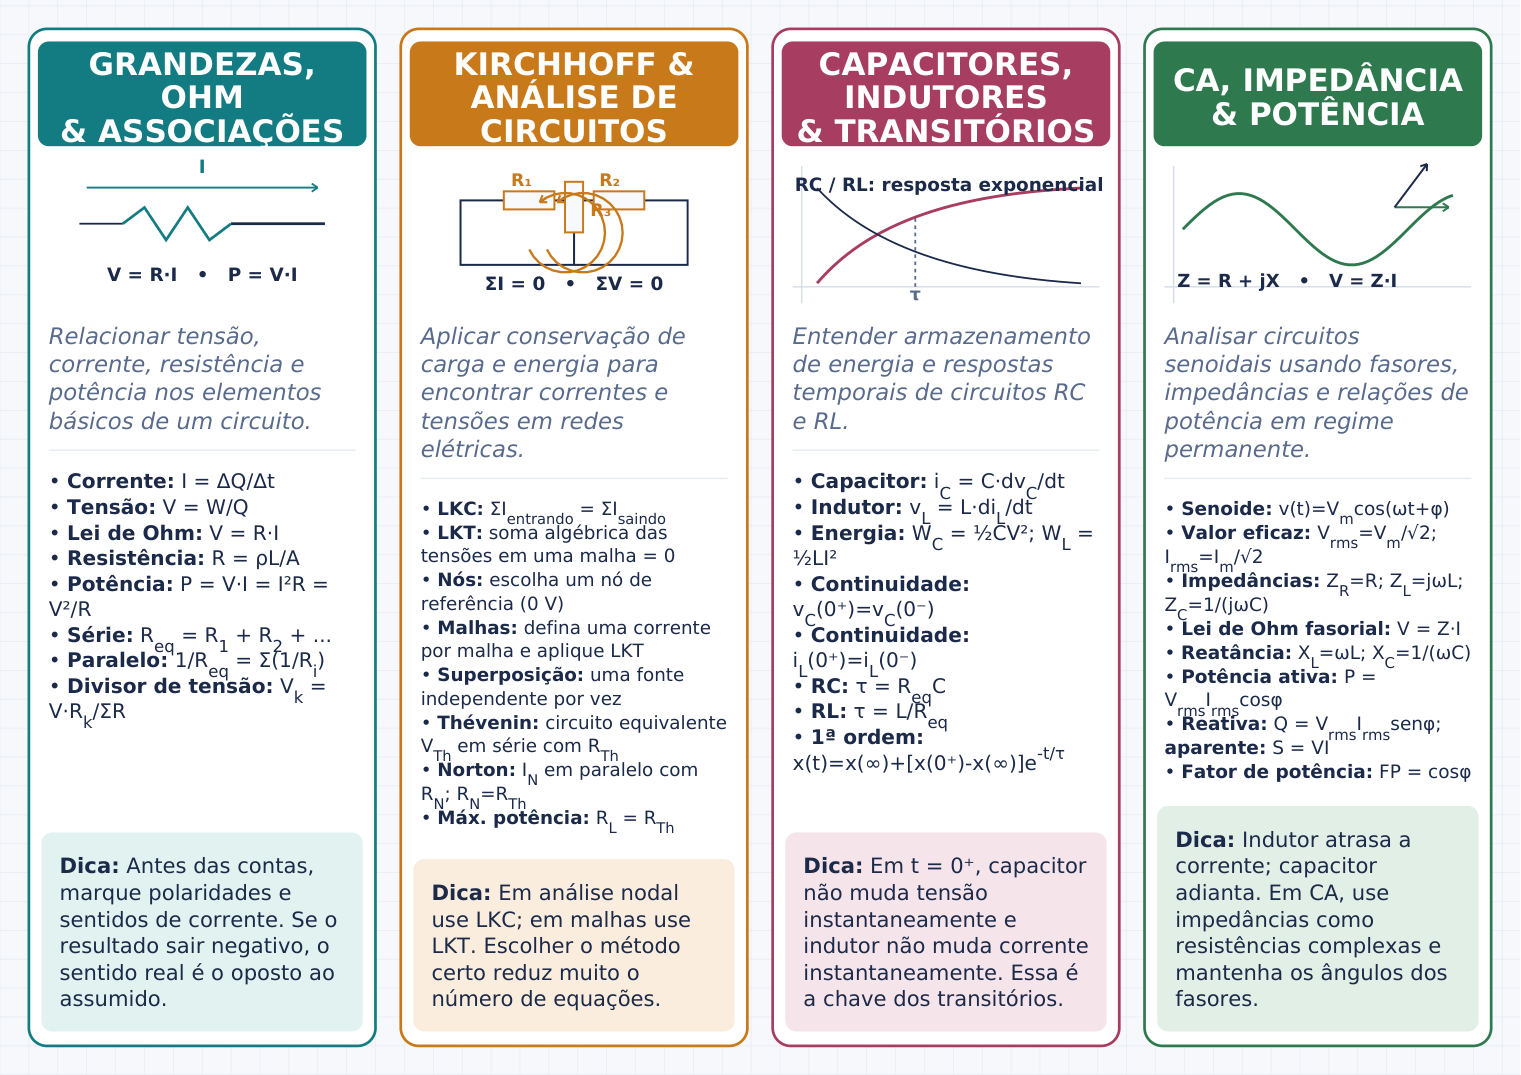

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Circuitos_Eletricos.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) LEI DE OHM: R = 10 Ohm, I = 2 A
   V = 20 V | P = 40 W

2) ASSOCIACOES
   serie: 60.0 ohm | paralelo: 5.45 ohm

3) DIVISOR DE TENSAO: V = 12 V com R1=1k e R2=3k
   V sobre R2 = 9.00 V

4) KIRCHHOFF (analise de malhas) com numpy
   i1 = 0.764 A | i2 = -0.109 A

5) THEVENIN: Vth e Rth vistos pela carga
   Rl =  25 ohm -> Il = 160.0 mA | P = 0.64 W
   Rl =  50 ohm -> Il = 120.0 mA | P = 0.72 W
   Rl = 100 ohm -> Il = 80.0 mA | P = 0.64 W
   (maxima potencia quando Rl = Rth = 50 ohm)

6) TRANSITORIO RC: carga de 1 kOhm . 100 uF em 12 V


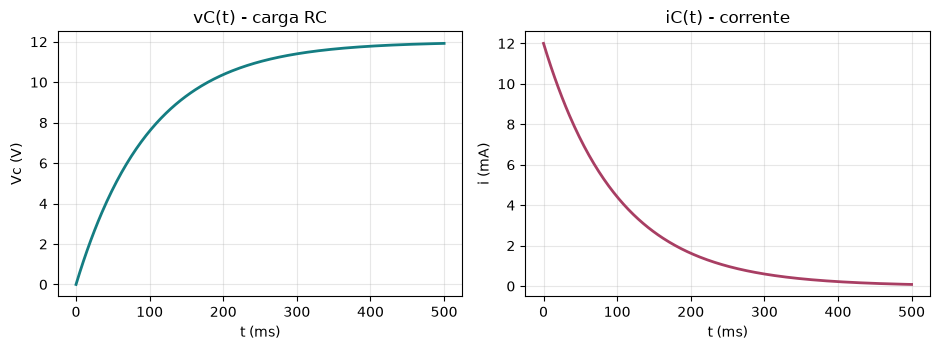


7) CORRENTE ALTERNADA: fasores, RLC serie (f = 60 Hz)
   Z = 101.2 ohm ang(-8.7°)
   I = 1.255 A | FP = cos(phi) = 0.988

OK - circuitos analisados com numpy.


In [3]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("1) LEI DE OHM: R = 10 Ohm, I = 2 A")
V = 10*2
print(f"   V = {V} V | P = {V*2} W")

print("\n2) ASSOCIACOES")
R1, R2, R3 = 10.0, 20.0, 30.0
Rs = R1 + R2 + R3
Rp = 1/(1/R1 + 1/R2 + 1/R3)
print(f"   serie: {Rs:.1f} ohm | paralelo: {Rp:.2f} ohm")

print("\n3) DIVISOR DE TENSAO: V = 12 V com R1=1k e R2=3k")
V_s, R_a, R_b = 12.0, 1e3, 3e3
Vb = V_s*R_b/(R_a + R_b)
print(f"   V sobre R2 = {Vb:.2f} V")

print("\n4) KIRCHHOFF (analise de malhas) com numpy")
# malha 1: 10*i1 + 5*(i1-i2) = 12 ; malha 2: 5*(i2-i1) + 15*i2 = -6
A = np.array([[15, -5], [-5, 20]])
B = np.array([12, -6])
i = np.linalg.solve(A, B)
print(f"   i1 = {i[0]:.3f} A | i2 = {i[1]:.3f} A")

print("\n5) THEVENIN: Vth e Rth vistos pela carga")
V_src, R_th = 12.0, 50.0
for Rl in (25, 50, 100):
    Il = V_src/(R_th + Rl)
    print(f"   Rl = {Rl:>3} ohm -> Il = {Il*1000:.1f} mA | P = {Il**2*Rl:.2f} W")
print("   (maxima potencia quando Rl = Rth = 50 ohm)")

print("\n6) TRANSITORIO RC: carga de 1 kOhm . 100 uF em 12 V")
R, C, Vf = 1e3, 100e-6, 12.0
tau = R*C
t = np.linspace(0, 5*tau, 300)
vc = Vf*(1 - np.exp(-t/tau))
ic = (Vf/R)*np.exp(-t/tau)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax[0].plot(t*1e3, vc, color="#147D82", lw=2); ax[0].set_title("vC(t) - carga RC")
ax[0].set_xlabel("t (ms)"); ax[0].set_ylabel("Vc (V)"); ax[0].grid(alpha=.3)
ax[1].plot(t*1e3, ic*1e3, color="#A83E63", lw=2); ax[1].set_title("iC(t) - corrente")
ax[1].set_xlabel("t (ms)"); ax[1].set_ylabel("i (mA)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\n7) CORRENTE ALTERNADA: fasores, RLC serie (f = 60 Hz)")
f_ca, L, Cv = 60.0, 0.1, 50e-6
w = 2*np.pi*f_ca
ZL, ZC = 1j*w*L, 1/(1j*w*Cv)
Z = 100 + ZL + ZC
Vrms = 127
I = Vrms/Z
print(f"   Z = {abs(Z):.1f} ohm ang({np.degrees(np.angle(Z)):.1f}°)")
print(f"   I = {abs(I):.3f} A | FP = cos(phi) = {np.cos(np.angle(Z)):.3f}")
print("\nOK - circuitos analisados com numpy.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
